Moving away from `blochstate`.

In [1]:
# import all the E9 stuff
import logging
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path
import time
from scipy.linalg import eigh
from scipy.interpolate import interp1d
from scipy.integrate import tplquad

# User defined modules
E9path = Path("C:/", "Users", "ken92", "Documents", "Studies", "E5", "simulation", "E9_simulations")
if str(E9path) not in sys.path:
    sys.path.insert(1, str(E9path))
import E9_fn.E9_constants as E9c
import E9_fn.E9_atom as E9a
import E9_fn.E9_cooltrap as E9ct
import E9_fn.plane_wave_expansion.blochstate_class as bsc
import E9_fn.polarizabilities_calculation as E9pol
# import E9_fn.datasets.transition_line_data as TLData
from E9_fn import util

# Logging
logpath = '' # '' if not logging to a file
loglevel = logging.INFO
logroot = logging.getLogger()
list(map(logroot.removeHandler, logroot.handlers))
list(map(logroot.removeFilter, logroot.filters))
logging.basicConfig(filename = logpath, level = loglevel)

c:\Users\ken92\Documents\Studies\E5\simulation\E9_simulations\.venv\Lib\site-packages\gftool\precision.py:16: UserWarning: No quad precision datatypes available!
Some functions might be less accurate.
  warnings.warn("No quad precision datatypes available!\n"


# Inputs

In [2]:
species = "K40" # "Rb87", "K40"

# lattice parameters
# V1064Er = 5.            # 1064 lattice depth, in recoil energy
# V532Er = 3.             # 532 lattice depth, in recoil energy
# Rb kHz to Er
# V1064Er = 39.5 / 2.02781   # 25.213063
# V532Er = 0. / 8.11125    # 35.517929
# K kHz to Er
V1064Er = 39.5 / 4.4099   # 39.5
V532Er = 0 / 17.6394    # 35.517929
n0nom = 0               # peak density
# The superlattice phase that determines the relative position between 1064 and 532 lattice
# 532 lattice is fixed at 0, so changing the pase by pi for 1064 restores the original lattice
phi12, phi23 = 0., 0.
phi12, phi23 = 0, np.pi/5
# phi12, phi23 = np.pi*2/3, -np.pi*2/3    # decorated triangular lattice
ABoffset1064nom = 0     # max 0.011585 * V1064nom / 9 / np.sqrt(3) for Rb
B1_rel_int_1064 = 1     # relative intensity (field is sqrt of that) of 1064 B1
B1_rel_int_532  = 1     # relative intensity (field is sqrt of that) of 532 B1
B3_rel_int_1064 = 1     # relative intensity (field is sqrt of that) of 1064 B3
B3_rel_int_532  = 1     # relative intensity (field is sqrt of that) of 532 B3

# Basic simulation parameters
num = 5             # size of q-momentum space we consider: (-num, num) (usually 5)
k_center = (0, 0)
bandstart = 0       # starting from 0, inclusive
bandend = 3         # inclusive
# qverts_str = 'E9c.Kp/E9c.k_lw, E9c.Kp2/E9c.k_lw, E9c.Kp3/E9c.k_lw, E9c.Kp4/E9c.k_lw, E9c.Kp5/E9c.k_lw, E9c.Kp6/E9c.k_lw, E9c.Kp/E9c.k_lw'
qverts_str = 'np.array([-np.sqrt(3)/2, 3/4]), np.array([-np.sqrt(3)/2, -3/4]), np.array([np.sqrt(3)/2, -3/4]), np.array([np.sqrt(3)/2, 3/4]), np.array([-np.sqrt(3)/2, 3/4])'

# Initialization
## Units

In [3]:
if species == "Rb87":
    all_units_dict = E9c.all_lat_unit_Rb87
    Er_1064 = E9c.E_r1064_Rb87
    Er_532 = E9c.E_r532_Rb87
elif species == "K40":
    all_units_dict = E9c.all_lat_unit_K40
    Er_1064 = E9c.E_r1064_K40
    Er_532 = E9c.E_r532_K40
else:
    raise ValueError("Unknown species: {}".format(species))
m_unit = all_units_dict["m_unit"]
l_unit = all_units_dict["l_unit"]
E_unit = all_units_dict["E_unit"]
f_unit = all_units_dict["f_unit"]
t_unit = all_units_dict["t_unit"]

V532nom = V532Er * Er_532 / E9c.hnobar / 1e3       # in kHz (i.e. V_SI / hbar / 1e3 / 2pi), assuming that polarizability is accounted for correctly
V1064nom = V1064Er * Er_1064  / E9c.hnobar / 1e3   # Note that setting this to 0 doesn't give you a proper band structure of 532 nm lattice, since you are now
                                # considering too many plane waves that don't actually contribute.
V532 = 2 * np.pi * V532nom * 1e3 / f_unit   # 2 * np.pi because I have f = E/hbar instead of E/h as normally defined
V1064 = 2 * np.pi * V1064nom * 1e3 / f_unit
ABoffset1064 = 2 * np.pi * ABoffset1064nom * 1e3 / f_unit
n0 = n0nom * l_unit**3

In [4]:
Exp_lib = {"species": species, "units_dict": all_units_dict
        , 'V532nom': V532nom, 'V1064nom': V1064nom, 'V532': V532, 'V1064': V1064
        , 'B1_rel_int_532': B1_rel_int_532, 'B1_rel_int_1064': B1_rel_int_1064 , 'B3_rel_int_532': B3_rel_int_532, 'B3_rel_int_1064': B3_rel_int_1064
        , 'n0nom': n0nom, 'n0': n0
        , 'ABoffset1064nom': ABoffset1064nom, 'ABoffset1064': ABoffset1064
        , 'phi12': phi12, 'phi23': phi23}

size = 2 * num + 1
bandnum = bandend - bandstart + 1 # number of bands interested in
qverts_arr = eval(qverts_str)

# Real space plots

In [5]:
a_tri_um = E9c.a_sw_tri * 1e6
uc_vertices = [a_tri_um * np.array([-np.sqrt(3) * 4 / 3, 0]),
               a_tri_um * np.array([-np.sqrt(3) / 2, 1]),
               a_tri_um * np.array([np.sqrt(3) / 3, 0]),
               a_tri_um * np.array([-np.sqrt(3) / 2, -1]),]
uc_vertices.append(uc_vertices[0])

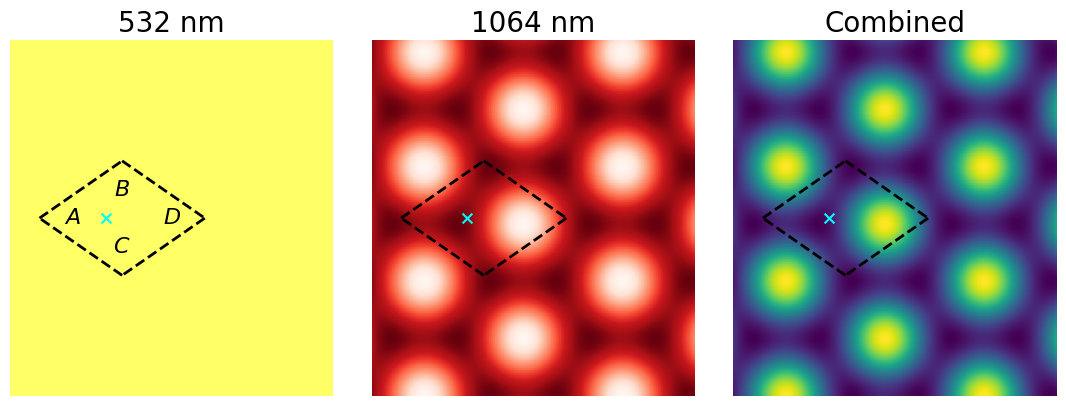

In [48]:
x_real = np.linspace(-1, 1, 500) * 1e-6
y_real = np.linspace(-1.1, 1.1, 500) * 1e-6
x_real_um = np.linspace(-1, 1, 500)
y_real_um = np.linspace(-1.1, 1.1, 500)

pos_delta = E9c.l_cell_lw * E9c.k1k * (phi12 / 2 / np.pi) + E9c.l_cell_lw * E9c.k3k * (phi23 / 2 / np.pi)
x_delta, y_delta = pos_delta # should be simple functions of phi12 and phi23
V_532_real = bsc.get_Vin(x_real, y_real, V532, B1_rel_int_532, B3_rel_int_532, 0, 0, 1)
V_1064_real = - bsc.get_Vin(x_real, y_real, V1064, B1_rel_int_1064, B3_rel_int_1064, x_delta, y_delta, 2)
V_super_real = V_532_real + V_1064_real

fig_real, (ax_532, ax_1064, ax_super) = plt.subplots(1, 3, figsize = (11, 4))
# fig_real.suptitle("Real space potential")
ax_532.set_ylabel("y (um)")
ax_1064.set_xlabel("x (um)")

for ax, V_real, ax_title, cmap_str in zip([ax_532, ax_1064, ax_super],
                                        [V_532_real, V_1064_real, V_super_real],
                                        ["532 nm", "1064 nm", "Combined"],
                                        ["summer_r", 'Reds_r', "viridis"],):
    ax.set_aspect("equal")
    im = ax.pcolormesh(x_real_um, y_real_um, V_real, cmap = cmap_str)
    # ax.scatter(0, 0, color = 'red', marker = '+', s = 50)   # origin
    ax.scatter(-a_tri_um * 2 / np.sqrt(3), 0, color = 'cyan', marker = 'x', s = 50)   # 1064 site
    
    # add unit cell
    for p1, p2 in zip(uc_vertices[:-1], uc_vertices[1:]):
        x1, y1 = p1
        x2, y2 = p2
        ax.plot([x1, x2], [y1, y2], color = "black", ls = "--", lw = 2)

    ax.set_title(ax_title, fontsize = 20)
    ax.axis("off")
    # fig_real.colorbar(im, ax = ax)

# add sublattice labels
ax_532.text(-a_tri_um * np.sqrt(3), 0, r"$A$", size = 16,
            horizontalalignment = "center", verticalalignment = "center")
ax_532.text(-a_tri_um * np.sqrt(3) / 2, a_tri_um / 2, r"$B$", size = 16,
            horizontalalignment = "center", verticalalignment = "center")
ax_532.text(-a_tri_um * np.sqrt(3) / 2, - a_tri_um / 2, r"$C$", size = 16,
            horizontalalignment = "center", verticalalignment = "center")
ax_532.text(0, 0, r"$D$", size = 16,
            horizontalalignment = "center", verticalalignment = "center")

fig_real.tight_layout()

# Finding Bloch states and band energies

Total number of points = 6525
--- 166.8038227558136 seconds ---


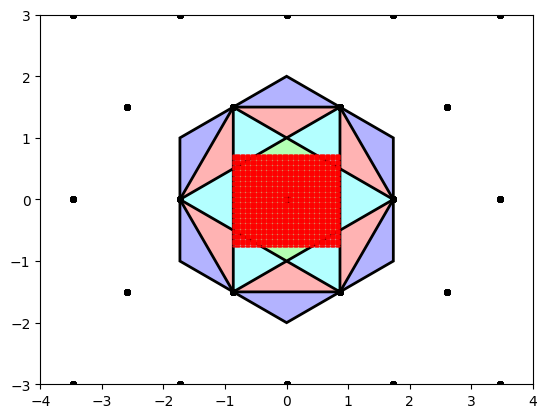

In [7]:
start_time = time.time()

# Generate qset
dq = 0.02
qsets = bsc.FindqArea(qverts_arr, dqx = dq, dqy = dq)
N_qsample = len(qsets)
print("Total number of points = {0}".format(N_qsample))
PlotBZinput = (qverts_str, qsets)
ax_BZ = bsc.PlotBZSubplot()
bsc.plot_qset(ax_BZ, qset = PlotBZinput, qset_type = "explicit")

# find non-interacting solution
e_values = np.zeros((len(qsets), bandnum), dtype = np.cdouble)
e_states = np.zeros((len(qsets), size**2, bandnum), dtype = np.cdouble)
e_states_ni = [[] for _ in range(bandnum)]  # a list of blochstate for each band

Hq_mmat, Hq_nmat, H_532, H_1064 = bsc.find_H_components(num, Exp_lib, center = k_center)
for i in range(len(qsets)):
    H = bsc.find_H(qsets[i], Exp_lib, Hq_mmat, Hq_nmat, H_532, H_1064)
    assert util.IsHermitian(H)
    e_values[i,:], e_states[i,:,:] = eigh(H, eigvals = (bandstart, bandend),
                                          overwrite_a = True, check_finite = False)

# Fix the gauge of eigenstates using parallel transport
e_states_fixed = bsc.fix_gauge_2d_grid(e_states, qsets, neighbor_dist = dq * 1.4)   # Using 1.5 is not good since 1.5 > sqrt(2)
for i in range(len(qsets)):
    for j, bandN in enumerate(range(bandstart, bandend + 1)):
        e_states_ni[j].append(bsc.blochstate(e_states[i,:,j], q = qsets[i], center = k_center, N = bandN, E = e_values[i,j], param = Exp_lib))
print("--- {0} seconds ---".format((time.time() - start_time)))

I always get a `ComplexWarning` when running `.astype(np.double)`, but if my own check doesn't raise a warning all is good.

In [8]:
if not np.all(np.isreal(e_values)):
    logging.warning('Complex eigenvalue detected. Imaginary parts are discarded.')
e_values = e_values.astype(np.double)

C:\Users\ken92\AppData\Local\Temp\ipykernel_32960\1078986975.py:3: ComplexWarning: Casting complex values to real discards the imaginary part
  e_values = e_values.astype(np.double)


So far all the lists are organized in 1D, in the order of qsets. To plot things using e.g. pcolormesh(), the values need to be reorganized into a 2D grid that knows about the relative position between q points. This doesn't matter if each object is plotted independently, e.g. using quiver().

In [9]:
# Reconstruct grid for pcolormesh
qx_qsets = qsets[:, 0]
qy_qsets = qsets[:, 1]
qx_vals = np.unique(qx_qsets)
qy_vals = np.unique(qy_qsets)
nx = len(qx_vals)
ny = len(qy_vals)

# Map from coordinate to grid index
qx_to_i = {val: i for i, val in enumerate(qx_vals)}
qy_to_j = {val: j for j, val in enumerate(qy_vals)}

def to_qxy_grid(arr, fill_value = np.nan):
    grid = np.full((ny, nx), fill_value)
    for k in range(len(arr)):
        i = qx_to_i[qx_qsets[k]]
        j = qy_to_j[qy_qsets[k]]
        grid[j, i] = arr[k]     # row = y, col = x
    return grid

## Band structure plot
I'm not sure about the energy at zero yet

In [10]:
E2kHz = E_unit / E9c.hnobar / 1e3 # conversion factor from natural units to kHz
E_lowest = np.min(e_values)
E_kHz_offset = (e_values - E_lowest) * E2kHz
E_kHz_highest = np.max(E_kHz_offset)
# fig_E = plt.figure(0, figsize=(10,7))
# fig_E.clf()
# fig_E.suptitle(f"Full BZ, {species}")

# ax_E = fig_E.add_subplot(111, projection = '3d')
# # Add BZ boundary
# bz1qx, bz1qy = [q[0] for q in E9c.BZ1_vertices], [q[1] for q in E9c.BZ1_vertices]
# for i in range(3):
#     ax_E.plot(bz1qx, bz1qy, np.ones_like(bz1qx) * E_kHz_highest * i / 2, '-k', alpha = 0.5)
# for i in range(bandnum):
#     ax_E.plot_trisurf(qsets[:, 0], qsets[:, 1], E_kHz_offset[:, i]) # TODO: try plotly
# ax_E.set_xlabel('q_x', fontsize = 15)
# ax_E.set_ylabel('q_y', fontsize = 15)
# ax_E.set_zlabel('E/h (kHz)', fontsize = 15)

# ax_E.set_title((rf'$V_{{532}}$ = {V532nom:.3f} kHz (${V532Er}\ E_r$), V1064 = {V1064nom:.3f} kHz (${V1064Er}\ E_r$)'
#                 '\n'
#                 rf'AB offset = {float(ABoffset1064nom):.3f} kHz, $\phi_{{12}} = {phi12:.3f}$, $\phi_{{23}} = {phi23:.3f}$'))

In [73]:
E_lowest * E2kHz

np.float64(-4.662431684110146)

# Integral of density of states

In [49]:
mu_kHz_range = np.linspace(0, 20, 100)

In [ ]:
all_energies = E_kHz_offset.flatten()
counts, bin_edges = np.histogram(all_energies, bins = 1000)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
cumulative_density = np.cumsum(counts) / N_qsample
n_hom_mu_kHz = interp1d(
    bin_centers, 
    cumulative_density, 
    kind='linear', 
    bounds_error=False, 
    fill_value=(0, cumulative_density[-1])
)

In [59]:
n1D_P_in_a_box = np.sqrt(8 * E9c.m_K40 * 6e3 * E9c.hnobar) / E9c.hnobar
print(f"number of particles per um in a flat potential: {n1D_P_in_a_box / 1e6:.3f} / um")
print(f"number of sites per um^2 in our lattice: {E9c.n_site_hex / 1e12:.3f} / um^2")

N_hom_mu_kHz = lambda x: n_hom_mu_kHz(x) * n1D_P_in_a_box / 1e6 * E9c.n_site_hex / 1e12

number of particles per um in a flat potential: 2.193 / um
number of sites per um^2 in our lattice: 4.590 / um^2


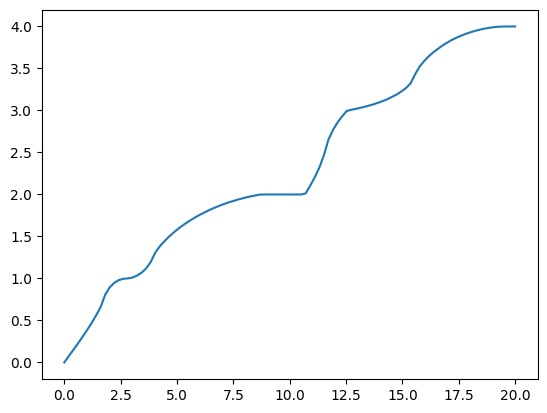

In [60]:
density_local = n_hom_mu_kHz(mu_kHz_range)
plt.plot(mu_kHz_range, density_local)

# Local density approximation

In [61]:
fx_trap_Rb = 49.83    # Measured 2026/01/09
fy_trap_Rb = 70.65    # Measured 2026/01/09
fz_trap_Rb = 256.08   # Measured 2026/01/13
N_Rb = 1e5
N_K40 = 8e4

In [62]:
# Rb stuff
wx_trap_Rb = fx_trap_Rb * 2 * np.pi
wy_trap_Rb = fy_trap_Rb * 2 * np.pi
wz_trap_Rb = fz_trap_Rb * 2 * np.pi
Rx_TF_Rb = E9ct.fermi_radius_Rb(wx_trap_Rb, N_Rb)
Ry_TF_Rb = E9ct.fermi_radius_Rb(wy_trap_Rb, N_Rb)
Rz_TF_Rb = E9ct.fermi_radius_Rb(wz_trap_Rb, N_Rb)

# K stuff
alpha_ratio = E9pol.alpha_s_Rb_5S1o2(1064e-9) / E9pol.alpha_s_K_4S1o2(1064e-9)
print(alpha_ratio)
fx_trap_K = fx_trap_Rb * np.sqrt(E9c.m_Rb87 / E9c.m_K40 * alpha_ratio)
fy_trap_K = fy_trap_Rb * np.sqrt(E9c.m_Rb87 / E9c.m_K40 * alpha_ratio)
fz_trap_K = fz_trap_Rb * np.sqrt(E9c.m_Rb87 / E9c.m_K40 * alpha_ratio)
wx_trap_K = fx_trap_K * 2 * np.pi
wy_trap_K = fy_trap_K * 2 * np.pi
wz_trap_K = fz_trap_K * 2 * np.pi
Rx_TF_K = E9ct.fermi_radius_K40(wx_trap_K, N_K40)
Ry_TF_K = E9ct.fermi_radius_K40(wy_trap_K, N_K40)
Rz_TF_K = E9ct.fermi_radius_K40(wz_trap_K, N_K40)

fbar_trap_K = (fx_trap_K * fy_trap_K * fz_trap_K)**(1/3)

print(f"(For K) f_x = {fx_trap_K:.3f}, f_y = {fy_trap_K:.3f}, f_z = {fz_trap_K:.3f}, fbar = {fbar_trap_K:.3f}")
print("Thomas-Fermi radii without lattice (in um):")
print(f"    Rb: Rx = {Rx_TF_Rb * 1e6:.3f}, Ry = {Ry_TF_Rb * 1e6:.3f}, Rz = {Rz_TF_Rb * 1e6:.3f}")
print(f"   K40: Rx = {Rx_TF_K * 1e6:.3f}, Ry = {Ry_TF_K * 1e6:.3f}, Rz = {Rz_TF_K * 1e6:.3f}")

1.1435015937973818
(For K) f_x = 78.579, f_y = 111.411, f_z = 403.824, fbar = 152.338
Thomas-Fermi radii without lattice (in um):
    Rb: Rx = 8.463, Ry = 7.360, Rz = 4.397
   K40: Rx = 22.450, Ry = 18.854, Rz = 9.903


In [67]:
# triple integral and such
# scale factors to make things on the order of unity
scw = 1e3
scR = 1e6
scV = E9c.m_K40 * (scw / scR)**2 / E9c.hnobar / 1e3
wx_kHz, wy_kHz, wz_kHz = wx_trap_K / scw, wy_trap_K / scw, wz_trap_K / scw
mu_kHz = 7
Rx_um = np.sqrt(2 * mu_kHz * 1e3 * E9c.hnobar / (E9c.m_K40 * wx_trap_K**2)) * scR
print(Rx_um)

def Vhar_kHz_zyx(z, y, x):
    return 1/2 * ((wx_kHz * x)**2 + (wy_kHz * y)**2 + (wz_kHz * z)**2) * scV

def muLDA_zyx(z, y, x):
    return max(0, mu_kHz - Vhar_kHz_zyx(z, y, x))

def nLDA_zyx(z, y, x):
    return n_hom_mu_kHz(muLDA_zyx(z, y, x))

assert np.isclose(Vhar_kHz_zyx(0, 0, Rx_um) - mu_kHz, 0)

23.94669363103746


In [68]:
trap_DOS_factor = (4 * np.pi * np.sqrt(2)) / (wx_kHz * wy_kHz * wz_kHz * scV**(3/2))

# 2. Define the 1D integrand over potential energy U
def dN_dU(U):
    # The local chemical potential is just global mu minus the local potential U
    local_mu = mu_kHz - U
    
    # Volume element scaled by the density
    return N_hom_mu_kHz(local_mu) * trap_DOS_factor * np.sqrt(U)

# 3. Create a dense 1D grid of potential energies from trap center (0) to trap edge (mu)
# 10,000 points is more than enough to be highly accurate
U_grid = np.linspace(0, mu_kHz, 10000)

# 4. Evaluate the integrand everywhere simultaneously (Vectorized)
integrand_vals = dN_dU(U_grid)

# 5. Integrate using the trapezoidal rule
N_at_mu_kHz = np.trapz(integrand_vals, U_grid)

print(f"N = {N_at_mu_kHz}")

N = 74441.51569996937


C:\Users\ken92\AppData\Local\Temp\ipykernel_32960\2990368202.py:19: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  N_at_mu_kHz = np.trapz(integrand_vals, U_grid)
